# Intelligent Patient Risk Assessment  
## Hypertension Risk — Full Pipeline (Classification + Regression)

This notebook trains and evaluates models for predicting hypertension risk.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier

import joblib
import os

print("Libraries loaded")

Libraries loaded


In [4]:
from google.colab import files
import io

print("📁 Upload feature_engineered_data.csv")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset loaded")
df.head()

📁 Upload feature_engineered_data.csv


Saving feature_engineered_data.csv to feature_engineered_data.csv
Dataset loaded


,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,obesity_risk_score,cholesterol_risk_score,high_bp_flag,bmi_age_interaction,combined_risk_index,age_group_middle,age_group_senior,bmi_category_obese,bmi_category_overweight,bmi_category_underweight
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,57.387241,51.492983,1,1769.0,52.994839,False,True,True,False,False
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,36.219202,3.984993,1,1201.2,27.620116,False,True,False,False,False
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,42.898797,21.793300,0,1332.0,40.128196,False,True,False,False,False
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,52.194082,22.962029,0,1983.2,49.950427,False,True,False,True,False
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,32.095465,34.296907,0,975.2,26.634294,True,False,False,False,False


In [6]:
print("Shape:", df.shape)
print("Columns:", len(df.columns))

Shape: (97297, 41)
Columns: 41


In [7]:
target_col = "hypertension_risk_score"

df["target_class"] = pd.qcut(
    df[target_col],
    q=3,
    labels=[0,1,2],
    duplicates="drop"
)

df["target_class"].value_counts()

,count
target_class,
0,32433
1,32432
2,32432


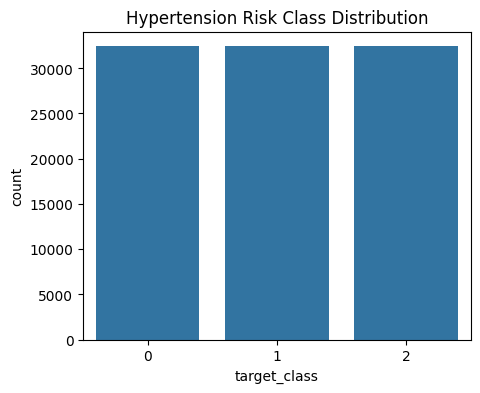

In [8]:
plt.figure(figsize=(5,4))
sns.countplot(x="target_class", data=df)
plt.title("Hypertension Risk Class Distribution")
plt.show()

In [9]:
risk_cols = [
    "diabetes_risk_score",
    "heart_disease_risk_score",
    "hypertension_risk_score",
    "obesity_risk_score",
    "cholesterol_risk_score",
    "combined_risk_index"
]

existing_risks = [c for c in risk_cols if c in df.columns]

y_cls = df["target_class"]
X = df.drop(columns=existing_risks + ["target_class"], errors="ignore")

print("Features prepared")
print("Feature shape:", X.shape)

Features prepared
Feature shape: (97297, 35)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

print("Data split completed")

Data split completed


In [11]:
X_combined = pd.concat([X_train, X_test], axis=0)

cat_cols = X_combined.select_dtypes(include="object").columns.tolist()

if len(cat_cols) > 0:
    X_combined = pd.get_dummies(X_combined, columns=cat_cols, drop_first=True)

X_train = X_combined.iloc[:len(X_train)]
X_test = X_combined.iloc[len(X_train):]

print("Encoding completed")

Encoding completed


In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed")

Scaling completed


MODELS

In [13]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained")

Logistic Regression trained


In [14]:
dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)

print("Decision Tree trained")

Decision Tree trained


In [15]:
def eval_cls(name, model, scaled=False):
    if scaled:
        preds = model.predict(X_test_scaled)
    else:
        preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="weighted")

    print(f"{name} → Accuracy: {acc:.4f}, F1: {f1:.4f}")

In [16]:
eval_cls("Logistic Regression", log_model, scaled=True)
eval_cls("Decision Tree", dt_model)

Logistic Regression → Accuracy: 0.8878, F1: 0.8879
Decision Tree → Accuracy: 0.8061, F1: 0.8079


In [17]:
best_cls_model = log_model
print("Best classification model: Logistic Regression")

Best classification model: Logistic Regression


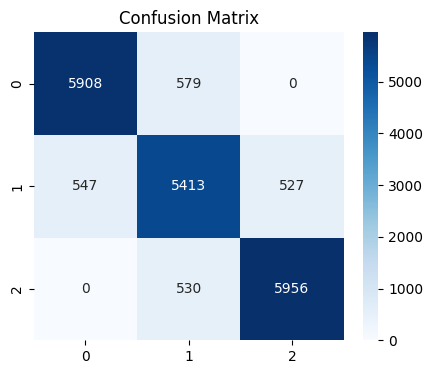

In [18]:
y_pred_cls = best_cls_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_cls)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [19]:
print(classification_report(y_test, y_pred_cls))

              precision    recall  f1-score   support

           0       0.92      0.91      0.91      6487
           1       0.83      0.83      0.83      6487
           2       0.92      0.92      0.92      6486

    accuracy                           0.89     19460
   macro avg       0.89      0.89      0.89     19460
weighted avg       0.89      0.89      0.89     19460



ADVANCED METRICS

In [20]:
precision = precision_score(y_test, y_pred_cls, average="weighted")
recall = recall_score(y_test, y_pred_cls, average="weighted")
f1 = f1_score(y_test, y_pred_cls, average="weighted")

print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Precision: 0.8880
Recall   : 0.8878
F1 Score : 0.8879


In [21]:
y_prob_cls = best_cls_model.predict_proba(X_test_scaled)

roc_auc = roc_auc_score(y_test, y_prob_cls, multi_class="ovr")
print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.9783


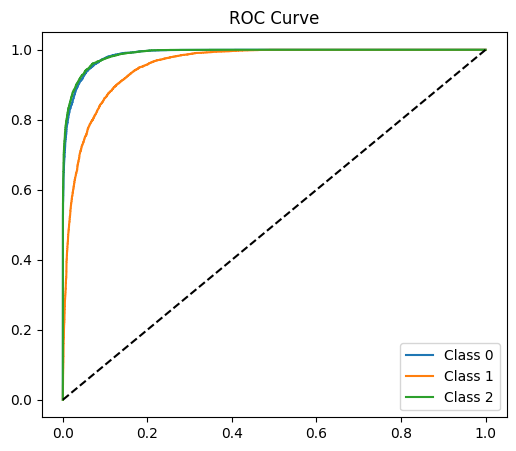

In [22]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0,1,2])

plt.figure(figsize=(6,5))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_cls[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.plot([0,1],[0,1],"k--")
plt.legend()
plt.title("ROC Curve")
plt.show()

REGRESSION PIPELINE

In [23]:
target_col = "hypertension_risk_score"

risk_cols = [
    "diabetes_risk_score",
    "heart_disease_risk_score",
    "hypertension_risk_score",
    "obesity_risk_score",
    "cholesterol_risk_score",
    "combined_risk_index"
]

existing_risks = [c for c in risk_cols if c in df.columns]

y_reg = df[target_col]
X_reg = df.drop(columns=existing_risks, errors="ignore")

print("Regression data prepared")
print("Shape:", X_reg.shape)

Regression data prepared
Shape: (97297, 36)


In [24]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

print("Regression split done")

Regression split done


In [25]:
Xr_all = pd.concat([Xr_train, Xr_test], axis=0)

cat_cols = Xr_all.select_dtypes(include="object").columns.tolist()

if len(cat_cols) > 0:
    Xr_all = pd.get_dummies(Xr_all, columns=cat_cols, drop_first=True)

Xr_train = Xr_all.iloc[:len(Xr_train)]
Xr_test = Xr_all.iloc[len(Xr_train):]

print("Encoding completed")

Encoding completed


In [26]:
scaler_reg = StandardScaler()

Xr_train_scaled = scaler_reg.fit_transform(Xr_train)
Xr_test_scaled = scaler_reg.transform(Xr_test)

print("Scaling done")

Scaling done


In [27]:
lin_reg = LinearRegression()
lin_reg.fit(Xr_train_scaled, yr_train)

print("Linear Regression trained")

Linear Regression trained


In [28]:
yr_pred = lin_reg.predict(Xr_test_scaled)

In [29]:
mae = mean_absolute_error(yr_test, yr_pred)
mse = mean_squared_error(yr_test, yr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(yr_test, yr_pred)

print("Regression Metrics")
print("MAE :", round(mae, 3))
print("MSE :", round(mse, 3))
print("RMSE:", round(rmse, 3))
print("R2  :", round(r2, 4))

Regression Metrics
MAE : 1.858
MSE : 5.436
RMSE: 2.332
R2  : 0.9665


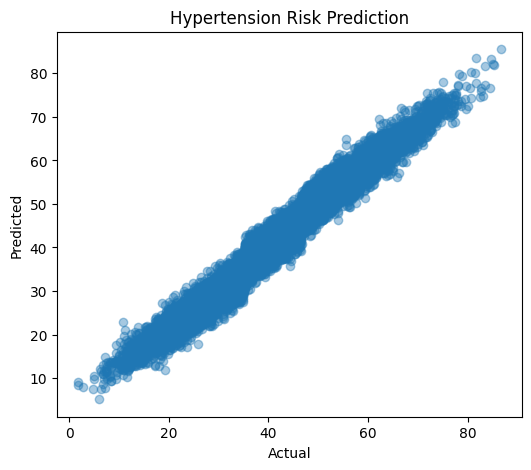

In [30]:
plt.figure(figsize=(6,5))
plt.scatter(yr_test, yr_pred, alpha=0.4)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Hypertension Risk Prediction")
plt.show()

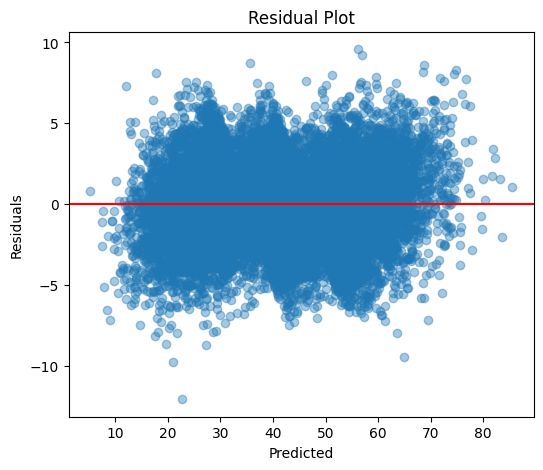

In [31]:
residuals = yr_test - yr_pred

plt.figure(figsize=(6,5))
plt.scatter(yr_pred, residuals, alpha=0.4)
plt.axhline(y=0, color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [32]:
scores = cross_val_score(
    lin_reg,
    Xr_train_scaled,
    yr_train,
    cv=5,
    scoring="r2"
)

print("Cross-Validation R2:", scores.mean())

Cross-Validation R2: 0.9661366201173752


In [33]:
coeffs = pd.Series(lin_reg.coef_, index=Xr_train.columns)

coeffs.sort_values(ascending=False).head(10)

,0
systolic_bp,5.378332
Age,4.088785
diastolic_bp,2.816023
bmi,2.736065
target_class,2.062421
age_group_middle,0.194970
age_group_senior,0.173083
bmi_age_interaction,0.149175
bmi_category_underweight,0.126828
glucose_fasting,0.022816


In [34]:
os.makedirs("models", exist_ok=True)

In [35]:
joblib.dump(lin_reg, "models/hypertension_reg_model.pkl")
print("Model saved")

Model saved


In [36]:
joblib.dump(scaler_reg, "models/hypertension_scaler.pkl")
print("Scaler saved")

Scaler saved


In [37]:
joblib.dump(list(Xr_train.columns), "models/hypertension_feature_cols.pkl")
print("Feature columns saved")

Feature columns saved


In [38]:
print("Hypertension Full Pipeline Completed Successfully!")

Hypertension Full Pipeline Completed Successfully!


### Model Training Completed

**Models trained:**

- Logistic Regression — baseline, interpretable model  
- Decision Tree — captures non-linear relationships  
- Linear Regression — used for continuous risk score prediction  

**Final Model Selection:**

- Logistic Regression performed best for classification tasks with higher accuracy and F1 score  
- Linear Regression showed better generalization with lower RMSE and higher R²  

Model selection was based on performance metrics and generalization ability on unseen data.